In [2]:
import pandas as pd

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [34]:
df = pd.read_csv("../data/cardekho_dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (15411, 14)


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [36]:
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

print(df.columns.tolist())

['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


In [37]:
from sklearn.preprocessing import LabelEncoder
import joblib

encoders = {}

categorical_columns = [
    "car_name",
    "brand",
    "model",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

joblib.dump(encoders, "../model/encoders.pkl")

print("✅ Encoders saved")

✅ Encoders saved


In [35]:
df = pd.read_csv("../data/cardekho_dataset.csv")

In [6]:
print(df.columns.tolist())

['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


In [7]:
# First 10 Records

df.head(10)


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
5,5,Maruti Wagon R,Maruti,Wagon R,8,35000,Individual,Petrol,Manual,18.90,998,67.10,5,350000
6,6,Hyundai i10,Hyundai,i10,8,40000,Dealer,Petrol,Manual,20.36,1197,78.90,5,315000
7,7,Maruti Wagon R,Maruti,Wagon R,3,17512,Dealer,Petrol,Manual,20.51,998,67.04,5,410000
8,8,Hyundai Venue,Hyundai,Venue,2,20000,Individual,Petrol,Automatic,18.15,998,118.35,5,1050000
9,12,Maruti Swift,Maruti,Swift,4,28321,Dealer,Petrol,Manual,16.60,1197,85.00,5,511000


In [8]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


✅ Encoders saved


In [10]:
# Statistical Summary

df.describe(include='all')

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,60.786451,15.235092,62.197391,6.036338,5.561648e+04,0.392252,2.474272,0.793265,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,30.618848,8.053460,36.322097,3.013291,5.161855e+04,0.510743,1.523609,0.404977,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+02,0.000000,0.000000,0.000000,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,34.000000,8.000000,26.000000,4.000000,3.000000e+04,0.000000,1.000000,1.000000,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,65.000000,18.000000,62.000000,6.000000,5.000000e+04,0.000000,1.000000,1.000000,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,78.000000,18.000000,92.000000,8.000000,7.000000e+04,1.000000,4.000000,1.000000,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,120.000000,31.000000,119.000000,29.000000,3.800000e+06,2.000000,4.000000,1.000000,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [11]:
# Missing Values

df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [12]:
# Duplicate Records

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


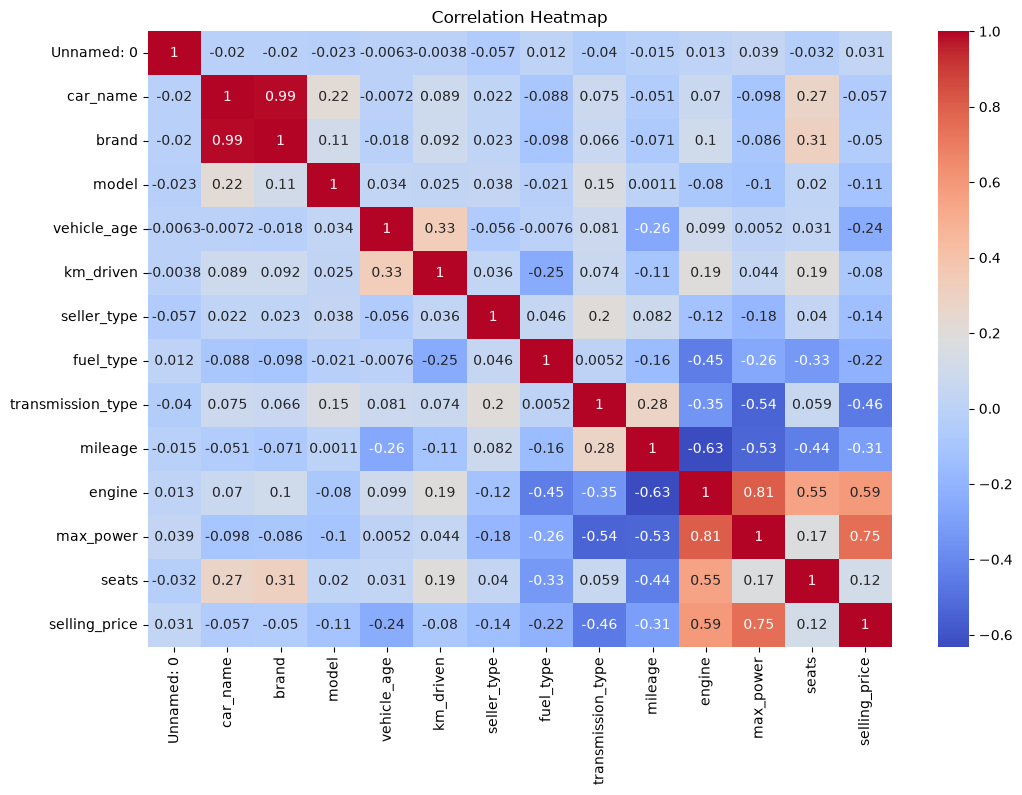

In [13]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

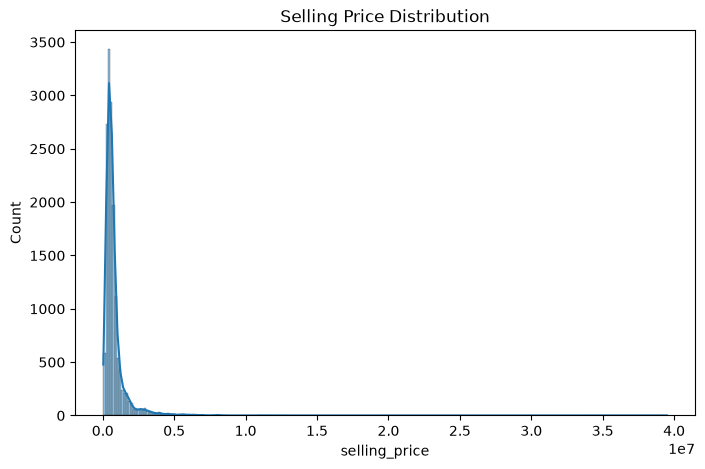

In [14]:
# Selling Price Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["selling_price"], kde=True)

plt.title("Selling Price Distribution")

plt.show()

In [15]:
print(df.columns)

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')


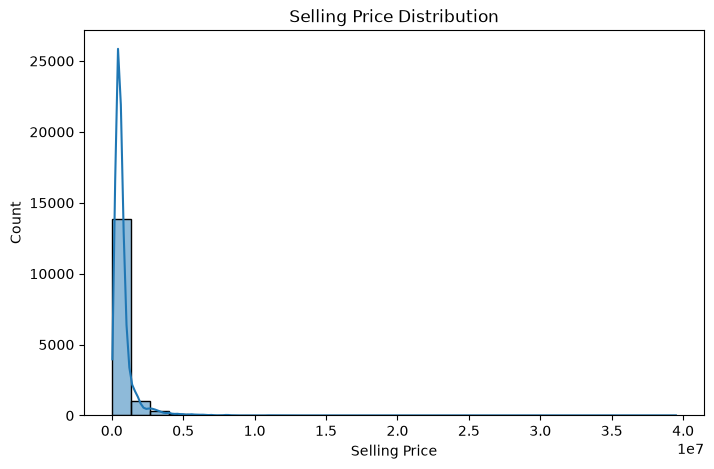

In [16]:
# Selling Price Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["selling_price"], kde=True, bins=30)

plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.show()

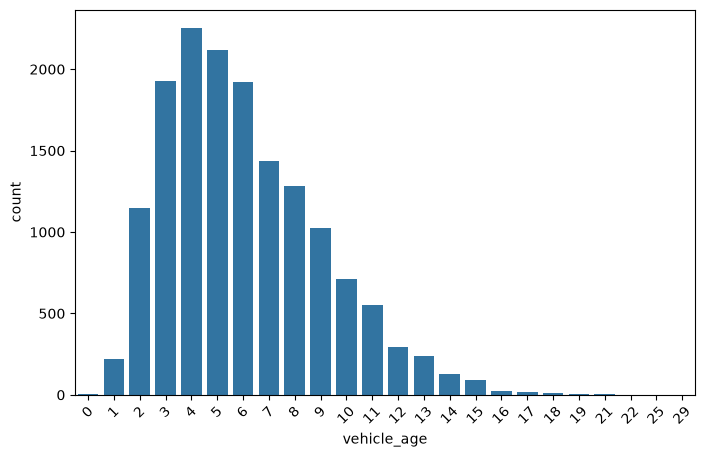

In [17]:
# Vehicle Age Distribution

plt.figure(figsize=(8,5))

sns.countplot(x=df["vehicle_age"])

plt.xticks(rotation=45)

plt.show()

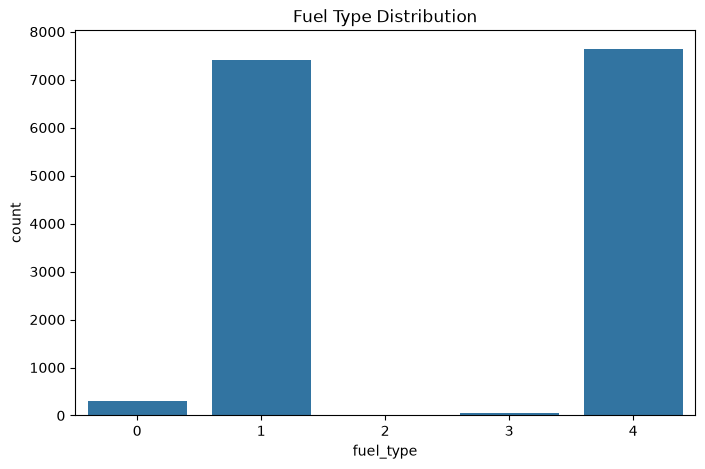

In [18]:
# Fuel Type Distribution

plt.figure(figsize=(8,5))

sns.countplot(x=df["fuel_type"])

plt.title("Fuel Type Distribution")

plt.show()

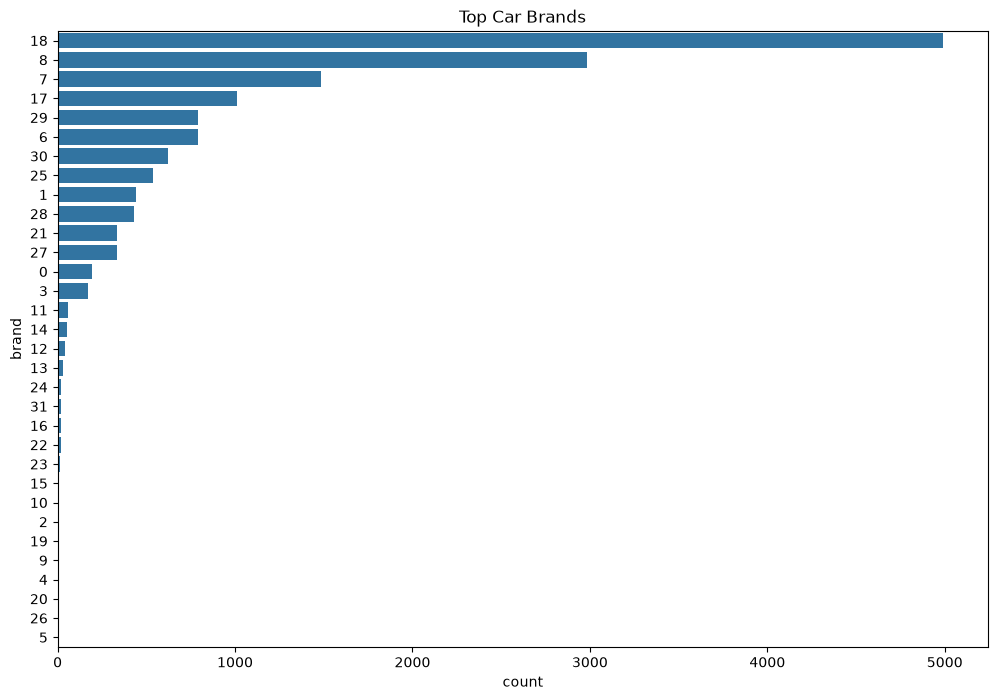

In [19]:
# Top Car Brands

plt.figure(figsize=(12,8))

sns.countplot(
    y=df["brand"],
    order=df["brand"].value_counts().index
)

plt.title("Top Car Brands")

plt.show()

In [20]:
# Remove unnecessary column

df.drop("Unnamed: 0", axis=1, inplace=True)

df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,65,18,7,9,120000,1,4,1,19.70,796,46.30,5,120000
1,34,8,54,5,20000,1,4,1,18.90,1197,82.00,5,550000
2,40,8,118,11,60000,1,4,1,17.00,1197,80.00,5,215000
3,65,18,7,9,37000,1,4,1,20.92,998,67.10,5,226000
4,20,6,38,6,30000,0,1,1,22.77,1498,98.59,5,570000


In [21]:
# Encode categorical columns

encoder = LabelEncoder()

categorical_columns = [
    "car_name",
    "brand",
    "model",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,65,18,7,9,120000,1,4,1,19.70,796,46.30,5,120000
1,34,8,54,5,20000,1,4,1,18.90,1197,82.00,5,550000
2,40,8,118,11,60000,1,4,1,17.00,1197,80.00,5,215000
3,65,18,7,9,37000,1,4,1,20.92,998,67.10,5,226000
4,20,6,38,6,30000,0,1,1,22.77,1498,98.59,5,570000


In [22]:
for col in categorical_columns:
    print("\n", col)
    print(df[col].unique()[:20])


 car_name
[ 65  34  40  20  79  39  37  76  38  96  90  68  84 113  66  77 116  32
  27  57]

 brand
[18  8  6 25 22 21 29 30  7 17  3 28 13  1  0 14 11 16 10 24]

 model
[  7  54 118  38 100 117  96  88  97  32  29  24  16  60  13  89  95  30
  25  14]

 seller_type
[1 0 2]

 fuel_type
[4 1 0 3 2]

 transmission_type
[1 0]


In [23]:
# Feature Matrix and Target

X = df.drop("selling_price", axis=1)

y = df["selling_price"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (15411, 12)
Target: (15411,)


In [24]:
print(df.columns.tolist())
print(X.columns.tolist())

['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']


In [25]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (12328, 12)
Testing : (3083, 12)


In [26]:
# Linear Regression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Model Trained")

Linear Regression Model Trained


In [27]:
print("Linear Regression Results")
print("-"*40)

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score :", r2_score(y_test, lr_pred))

Linear Regression Results
----------------------------------------
MAE : 270049.7834367239
MSE : 250603238588.25293
RMSE : 500602.87512983073
R2 Score : 0.6670971033619301


In [28]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Model Trained")

Decision Tree Model Trained


In [29]:
print("Decision Tree Results")
print("-"*40)

print("MAE :", mean_absolute_error(y_test, dt_pred))
print("MSE :", mean_squared_error(y_test, dt_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score :", r2_score(y_test, dt_pred))

Decision Tree Results
----------------------------------------
MAE : 123637.43918261434
MSE : 91594752143.22717
RMSE : 302646.2491808335
R2 Score : 0.8783249630886625


In [30]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Model Trained")

Random Forest Model Trained


In [31]:
print("Random Forest Results")
print("-"*40)

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

Random Forest Results
----------------------------------------
MAE : 99251.81593813437
MSE : 44474226389.486626
RMSE : 210889.1329336024
R2 Score : 0.9409201617895955


In [32]:
print(X.columns.tolist())

['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']


In [33]:
import joblib

joblib.dump(rf, "../model/model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


# Best Model & Justification

Among the three regression models, the Random Forest Regressor achieved the best performance.

- Highest R² Score: 0.9409
- Lowest MAE
- Lowest RMSE

Random Forest performed better because it combines multiple decision trees, reducing overfitting and improving prediction accuracy. Therefore, it is selected as the final model for car price prediction.

# Future Improvements

Possible improvements include:

- Collecting a larger and more diverse dataset.
- Hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Applying advanced feature engineering.
- Trying Gradient Boosting models such as XGBoost, LightGBM, and CatBoost.
- Deploying the trained model as a web application using Flask or Streamlit.